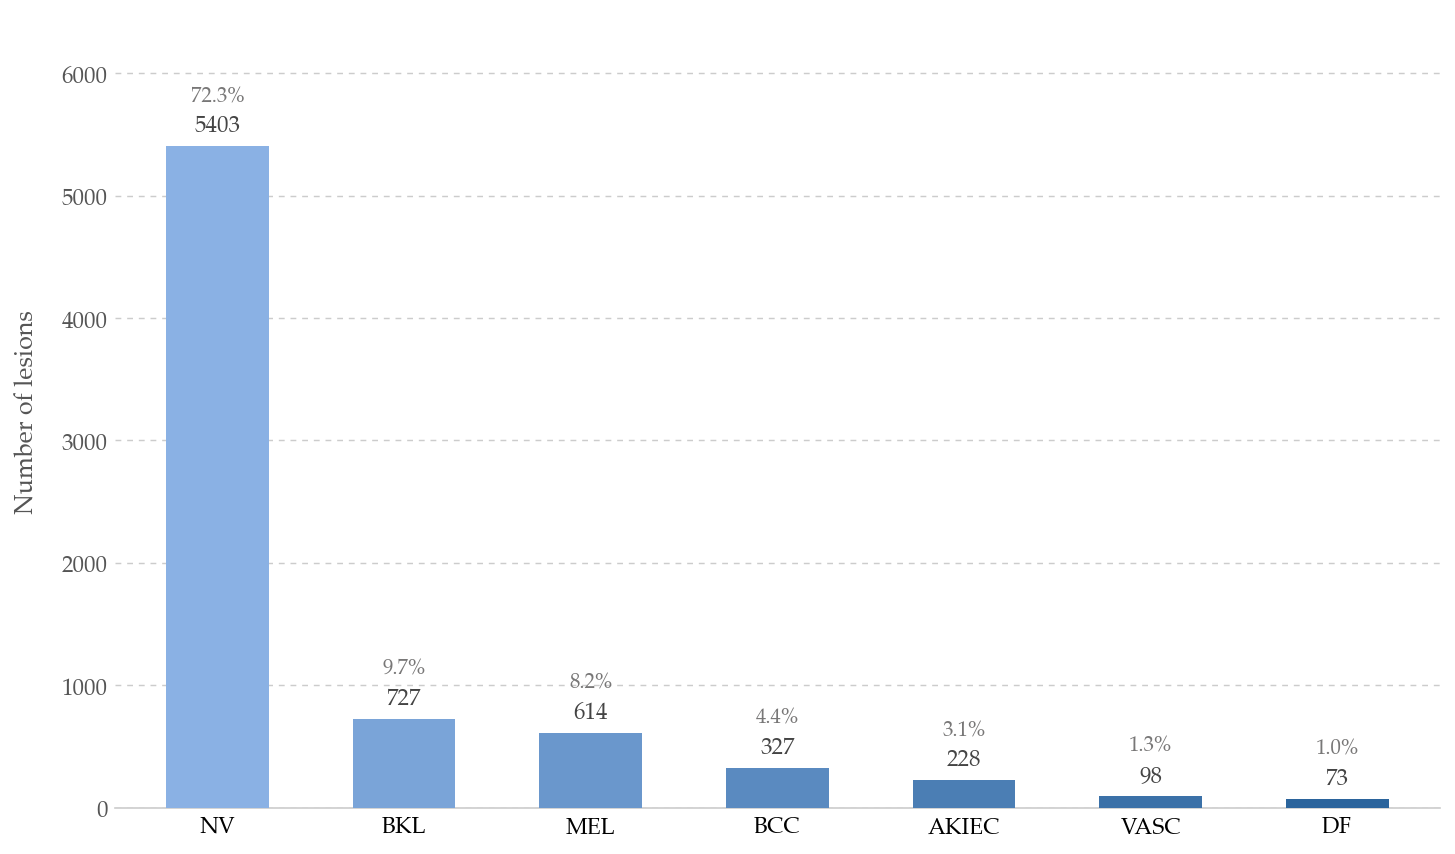

In [5]:
"""
HAM10000 Class Distribution Plot — Clean & Professional
=========================================================
Publication-quality figure for thesis inclusion.
"""

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# ── Configuration ──────────────────────────────────────────────────────────────

META_PATH = Path("../data/processed/HAM10000/one_image_per_lesion/HAM10000_metadata_one_per_lesion.csv")

CLASS_FULL_NAMES = {
    "nv":    "Melanocytic nevi",
    "mel":   "Melanoma",
    "bkl":   "Benign keratosis",
    "bcc":   "Basal cell carcinoma",
    "akiec": "Actinic keratoses",
    "vasc":  "Vascular lesions",
    "df":    "Dermatofibroma",
}

CLASS_SHORT = {
    "nv":    "NV",
    "mel":   "MEL",
    "bkl":   "BKL",
    "bcc":   "BCC",
    "akiec": "AKIEC",
    "vasc":  "VASC",
    "df":    "DF",
}

# Single-hue gradient from light to dark
GRADIENT_START = "#8ab1e4"   # light blue
GRADIENT_END   = "#2b649c"   # deep navy

plt.rcParams.update({
    "font.family":        "serif",
    "font.serif":         ["Palatino", "Palatino Linotype", "Book Antiqua", "DejaVu Serif"],
    "font.size":          12,
    "axes.labelsize":     12,
    "xtick.labelsize":    11,
    "ytick.labelsize":    11,
    "figure.dpi":         150,
    "savefig.dpi":        300,
    "savefig.bbox":       "tight",
})

# ── Load and prepare ───────────────────────────────────────────────────────────

df     = pd.read_csv(META_PATH)
counts = df["dx"].value_counts()

ordered_keys   = sorted(CLASS_FULL_NAMES.keys(), key=lambda k: counts.get(k, 0), reverse=True)
ordered_short  = [CLASS_SHORT[k]      for k in ordered_keys]
ordered_full   = [CLASS_FULL_NAMES[k] for k in ordered_keys]
ordered_counts = [counts.get(k, 0)    for k in ordered_keys]
total          = sum(ordered_counts)

# Build gradient colours across bars: light (most common) → dark (least common)
import matplotlib.colors as mcolors
n = len(ordered_keys)
start_rgb = np.array(mcolors.to_rgb(GRADIENT_START))
end_rgb   = np.array(mcolors.to_rgb(GRADIENT_END))
colours   = [mcolors.to_hex((1 - t) * start_rgb + t * end_rgb)
             for t in np.linspace(0, 1, n)]

# ── Plot ───────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

x = np.arange(len(ordered_keys))

bars = ax.bar(
    x, ordered_counts,
    width=0.55,
    color=colours,
    linewidth=0,
    zorder=3,
)

# Subtle horizontal grid — behind bars
ax.yaxis.grid(True, color="#cccccc", linewidth=0.7, linestyle="--", dashes=(4, 4), zorder=0)
ax.set_axisbelow(True)

# Count label above each bar
for xi, count in zip(x, ordered_counts):
    ax.text(
        xi, count + max(ordered_counts) * 0.012,
        f"{count}",
        ha="center", va="bottom",
        fontsize=11, color="#444444",
    )

# Percentage label, smaller and lighter
for xi, count in zip(x, ordered_counts):
    ax.text(
        xi, count + max(ordered_counts) * 0.06,
        f"{100 * count / total:.1f}%",
        ha="center", va="bottom",
        fontsize=10, color="#787777",
    )

# X-axis: bold abbreviation + full name on second line
ax.set_xticks(x)
ax.set_xticklabels(
    [f"{s}" for s in ordered_short],
    ha="center",
)

ax.set_ylabel("Number of lesions", labelpad=10, color="#555555")
ax.set_ylim(0, max(ordered_counts) * 1.20)
ax.set_xlim(-0.55, len(ordered_keys) - 0.45)

# Clean spine — only bottom
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_color("#cccccc")

ax.tick_params(axis="both", which="both", length=0)
ax.yaxis.set_tick_params(labelcolor="#555555")

plt.tight_layout(pad=1.5)

# ── Save ───────────────────────────────────────────────────────────────────────

# out_path = Path("../figures/ham10000_class_distribution.pdf")
# out_path.parent.mkdir(parents=True, exist_ok=True)
# plt.savefig(out_path, facecolor="white")
# print(f"Saved → {out_path}")

# plt.show()